In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000116675""","""ENSG00000116675_olink""",0.022487,0.022487,1.0
"""ENSG00000123609""","""ENSG00000123609_olink""",0.076186,0.076186,1.0
"""ENSG00000167851""","""ENSG00000167851_olink""",0.066067,0.066067,1.0
"""ENSG00000156711""","""ENSG00000156711_olink""",0.04852,0.04852,1.0
"""ENSG00000174990""","""ENSG00000174990_olink""",0.010786,0.010786,1.0
…,…,…,…,…
"""ENSG00000136542""","""ENSG00000136542_olink""",0.040315,0.040315,1.0
"""ENSG00000196576""","""ENSG00000196576_olink""",0.082542,0.082542,1.0
"""ENSG00000111144""","""ENSG00000111144_olink""",0.088107,0.088107,1.0


In [3]:
# Configuration and paths
mac = 20
abs_phenotypes = False
keep_fillna = False

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""chocolate""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
…,…,…,…,…
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#1f77b4""","""Flashzoi min across RNA (all)""",-1
"""regulatory""","""fz_blood_max""","""crimson""","""Flashzoi max across RNA (blood…",1


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_avg_ukbbgym.parquet"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_0_ukbbgym.parquet"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = (
    pl.scan_parquet(new_anno_local)
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_all_max = pl.max_horizontal(cs.starts_with('RNA:')),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_all_max', 'fz_all_mean'])
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_all_260218_0_ukbbgym.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_550428/920274466.py:18: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_all_max,fz_all_mean
str,str,f32,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.006898,0.001423,0.000735
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.013746,0.019601,0.00242
"""chr12:10309195:A:G""","""ENSG00000134539""",-0.01001,0.074744,0.016764
"""chr2:162198524:G:A""","""ENSG00000078098""",-0.002404,0.021105,0.005209
"""chr12:132769639:G:C""","""ENSG00000090615""",-0.004555,0.02279,0.001099
…,…,…,…,…
"""chr17:1645491:A:C""","""ENSG00000074660""",-0.033511,0.107099,0.013249
"""chr12:56007826:G:T""","""ENSG00000139531""",-0.021009,0.002934,0.003397
"""chr6:159982939:G:A""","""ENSG00000197081""",-0.008397,0.002198,0.000479


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
# keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Olink whitelist
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # VEP consequences
        # (pl.col('consequence_missense_variant') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        (pl.col('pangolin_score') < 0.2), # Remove splice variants from the non-coding analysis

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose regulatory region
        # (pl.col('encode_any_tf') == True),
        (pl.col('encode_enhancer') == True),
        # (pl.col('encode_promoter') == True),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
        promoterai_over = pl.col('promoterai'),
    )
)

# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'regulatory_nondir'] # CDS
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # missense
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
selected_categories = ['regulatory'] # regulatory
# selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory', 'regulatory_nondir', '3utr'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_550428/1580661940.py:88: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_550428/1580661940.py:97: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,fz_all_min,promoterai,abexp_min,promoterai_over,promoterai_under,id,fz_all_max,abexp_max,fz_all_mean
str,f32,f32,f32,f32,f32,str,f32,f32,f32
"""ENSG00000169814""",-0.002798,0.0,-0.013111,0.0,0.0,"""chr3:15637020:G:A""",0.001086,0.0,0.000941
"""ENSG00000160255""",-0.01358,0.0,-0.004254,0.0,0.0,"""chr21:44920277:C:T""",0.010094,0.002469,0.001882
"""ENSG00000116962""",-0.016505,0.0,-0.006261,0.0,0.0,"""chr1:236051275:C:T""",0.01017,0.0,0.001995
"""ENSG00000091129""",-0.00211,0.0,-0.006261,0.0,0.0,"""chr7:108285070:T:C""",0.006423,0.006871,0.002094
"""ENSG00000174837""",-0.137606,0.0,-0.040499,0.0,0.0,"""chr19:6926286:G:A""",0.008078,0.006871,0.022226
…,…,…,…,…,…,…,…,…,…
"""ENSG00000112769""",-0.005767,0.0,-0.02182,0.0,0.0,"""chr6:112206070:T:C""",0.003132,0.002372,0.001385
"""ENSG00000188783""",-0.003962,0.0,-0.011774,0.0,0.0,"""chr1:203481571:C:T""",0.009052,0.0,0.001075
"""ENSG00000131374""",null,0.0,-0.006189,0.0,0.0,"""chr3:17671268:T:C""",null,-0.00487,null


In [6]:
anno_fillna = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .with_columns(
        promoterai_under_is_na = pl.col('promoterai_is_na'),
        promoterai_over_is_na = pl.col('promoterai_is_na'),
    )
)
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_550428/3954935598.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr10:123008470:C:G""","""ENSG00000196177""","""promoterai_over""",1
"""chr3:140431715:G:T""","""ENSG00000158258""","""promoterai_over""",1
"""chr3:140128406:G:A""","""ENSG00000158258""","""promoterai_over""",1
"""chr3:167730736:C:G""","""ENSG00000163536""","""promoterai_over""",1
"""chr1:159923281:C:T""","""ENSG00000085552""","""promoterai_over""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation (skip if keep_fillna=True)
    # .pipe(lambda df: df if keep_fillna else df.join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='anti'
    # ))
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
        # annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="min", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_550428/887549084.py:51: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr16:89636830:G:A""","""ENSG00000015413""","""fz_all_min""",-0.011632,"""regulatory""",-1,1.206857e6
"""chr15:45050608:G:A""","""ENSG00000140263""","""fz_all_min""",-0.000329,"""regulatory""",-1,3.717842e6
"""chr20:56001455:A:T""","""ENSG00000054803""","""fz_all_min""",-0.0598,"""regulatory""",-1,291234.0
"""chr3:283947:T:C""","""ENSG00000134121""","""fz_all_min""",-0.002201,"""regulatory""",-1,2.655177e6
"""chr3:48479945:C:T""","""ENSG00000164054""","""fz_all_min""",-0.000388,"""regulatory""",-1,3.679154e6
…,…,…,…,…,…,…
"""chr12:70921165:G:C""","""ENSG00000153233""","""fz_all_min""",-0.016715,"""regulatory""",-1,938285.0
"""chr4:76195498:A:C""","""ENSG00000138760""","""fz_all_min""",-0.058953,"""regulatory""",-1,295955.0
"""chr11:10394104:A:T""","""ENSG00000133805""","""fz_all_min""",-0.000135,"""regulatory""",-1,3.827394e6


In [8]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""abexp_max""",4452373
"""abexp_min""",4452373
"""fz_all_min""",3894996
"""fz_all_max""",3894996
"""fz_all_mean""",3894996
"""promoterai_under""",178331
"""promoterai""",178331
"""promoterai_over""",178331


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


In [10]:
olink_appv.head().collect()

id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr12:24805471:G:A""","""ENSG00000060982_olink""",0.328067,1
"""chr12:122768837:C:G""","""ENSG00000139726_olink""",-1.312343,1
"""chr2:102332039:T:C""","""ENSG00000115604_olink""",0.249114,1
"""chr2:37346399:G:A""","""ENSG00000115828_olink""",1.00197,1
"""chr16:89195863:C:G""","""ENSG00000129910_olink""",-0.059154,1


## Average z-score by annotation rank bin

In [11]:
# Bin size: number of variants per rank bin
bin_size = 10_000  # Try 100 or 1000

In [16]:
# --- Join variant z-scores with annotation ranks, then bin by rank ---

id_region = anno.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
variant_zscores = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

print(f"Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

# Join with annotation ranks and bin
zscore_binned = (
    variant_zscores.lazy()
    .join(
        melted_anno.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor_rank_desc']),
        on=['id', 'region'],
        how='inner'
    )
    # Assign bin: rank 1–bin_size → bin 0, rank bin_size+1–2*bin_size → bin 1, etc.
    .with_columns(
        bin_id = ((pl.col('annotation_score_dircor_rank_desc') - 1) / bin_size).floor().cast(pl.Int64)
    )
    .group_by(['annotation', 'bin_id'])
    .agg(
        mean_zscore = pl.col('mean_pheno_value').mean(),
        sd_zscore = pl.col('mean_pheno_value').std(),
        se_zscore = pl.col('mean_pheno_value').std() / np.sqrt(bin_size),
        n_variants = pl.len(),
    )
    .with_columns(
        bin_center = (pl.col('bin_id') * bin_size + bin_size / 2).cast(pl.Float64),
        ci_lower = pl.col('mean_zscore') - 1.96*pl.col('se_zscore'),
        ci_upper = pl.col('mean_zscore') + 1.96*pl.col('se_zscore'),
    )
    .sort(['annotation', 'bin_id'])
    .collect()
)

print(f"Binned results: {zscore_binned.shape[0]} (annotation × bin) rows")
print(f"Annotations: {zscore_binned['annotation'].n_unique()}")
zscore_binned

Variant z-scores: 983167 variant-gene pairs
Binned results: 1404 (annotation × bin) rows
Annotations: 8


annotation,bin_id,mean_zscore,sd_zscore,se_zscore,n_variants,bin_center,ci_lower,ci_upper
str,i64,f32,f32,f64,u64,f64,f64,f64
"""abexp_max""",0,-0.012894,0.915767,0.009158,2477,5000.0,-0.030843,0.005055
"""abexp_max""",1,-0.034815,0.977243,0.009772,1886,15000.0,-0.053969,-0.015661
"""abexp_max""",2,-0.028323,0.957661,0.009577,2493,25000.0,-0.047093,-0.009552
"""abexp_max""",3,-0.027003,0.979878,0.009799,2333,35000.0,-0.046208,-0.007797
"""abexp_max""",4,-0.005456,0.990487,0.009905,2226,45000.0,-0.02487,0.013957
…,…,…,…,…,…,…,…,…
"""promoterai_under""",13,-0.000041,0.949371,0.009494,2168,135000.0,-0.018648,0.018567
"""promoterai_under""",14,-0.00223,0.94907,0.009491,2240,145000.0,-0.020832,0.016372
"""promoterai_under""",15,0.044705,0.93287,0.009329,2202,155000.0,0.02642,0.062989


## Plotting

In [17]:
plt_df = (
    zscore_binned
    .drop_nans()
    .with_columns(
        log_bin_center = pl.col('bin_center').log10(),
        log_bin_center_inv = (1 / pl.col('bin_center')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('bin_center')
)

plt_df

annotation,bin_id,mean_zscore,sd_zscore,se_zscore,n_variants,bin_center,ci_lower,ci_upper,log_bin_center,log_bin_center_inv,color,label,category
str,i64,f32,f32,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""abexp_max""",0,-0.012894,0.915767,0.009158,2477,5000.0,-0.030843,0.005055,3.69897,-3.69897,"""#b5de2b""","""AbExp max""","""regulatory"""
"""abexp_min""",0,-0.042237,0.98889,0.009889,2251,5000.0,-0.061619,-0.022854,3.69897,-3.69897,"""#b5de2b""","""AbExp min""","""regulatory"""
"""fz_all_max""",0,0.103226,1.06425,0.010643,2132,5000.0,0.082366,0.124085,3.69897,-3.69897,"""#1f77b4""","""Flashzoi max across RNA (all)""","""regulatory"""
"""fz_all_mean""",0,-0.102879,1.094343,0.010943,2250,5000.0,-0.124328,-0.08143,3.69897,-3.69897,"""#1f77b4""","""Flashzoi mean across RNA (all)""","""regulatory"""
"""fz_all_min""",0,-0.177047,1.056525,0.010565,2217,5000.0,-0.197755,-0.156339,3.69897,-3.69897,"""#1f77b4""","""Flashzoi min across RNA (all)""","""regulatory"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""abexp_max""",443,0.006964,0.96289,0.009629,1785,4.435e6,-0.011909,0.025837,6.646894,-6.646894,"""#b5de2b""","""AbExp max""","""regulatory"""
"""abexp_max""",444,-0.011701,0.94096,0.00941,2857,4.445e6,-0.030144,0.006742,6.647872,-6.647872,"""#b5de2b""","""AbExp max""","""regulatory"""
"""abexp_min""",444,0.008649,0.936088,0.009361,25322,4.445e6,-0.009698,0.026997,6.647872,-6.647872,"""#b5de2b""","""AbExp min""","""regulatory"""


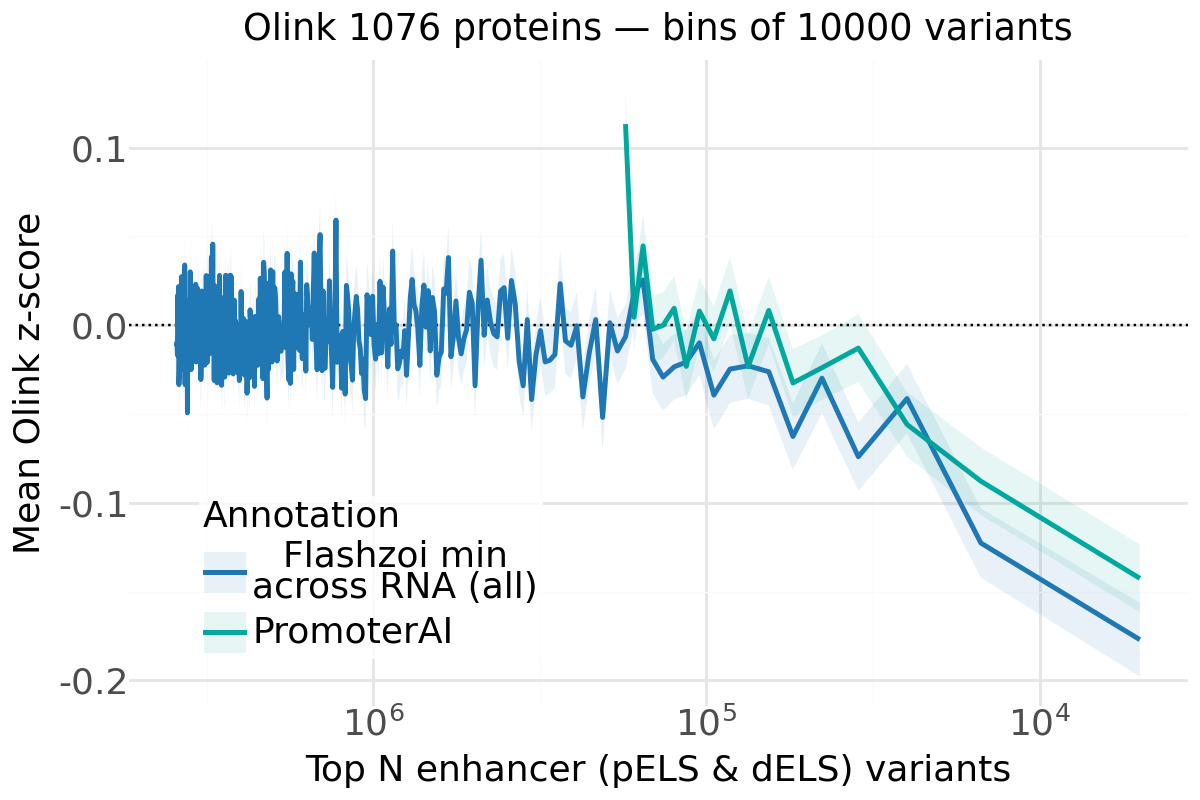

In [18]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('annotation').is_in(['gpn_score', 'verphylop', 'promoterai', 'fz_all_mean']))
        (pl.col('annotation').is_in(['gpn_score', 'verphylop', 'promoterai', 'fz_all_min']))
        # (pl.col('annotation').is_in(['gpn_score', 'verphylop', 'cadd_raw', 'promoterai_over', 'fz_all_max']))
    )
)

# Generate breaks and labels for x-axis (same style as odds ratio plot)
max_rank = zscore_binned['bin_center'].max()
min_rank = zscore_binned['bin_center'].min()
start_exp = int(np.floor(np.log10(1/max_rank)))
end_exp = int(np.ceil(np.log10(1/min_rank)))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(-b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plot_df,
        # aes(x='bin_id', y='mean_zscore')
        aes(x='log_bin_center_inv', y='mean_zscore')
    )
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Olink {olink_whitelist.shape[0]} proteins — bins of {bin_size} variants",
        y=f"Mean Olink z-score",
        x=f"Top N enhancer (pELS & dELS) variants",
        # x=f"Top N promoter (PLS & CA–H3K4me3) variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + theme_minimal()
    + theme(
        figure_size=(6, 4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.1),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)